## Load the model

In [ ]:
# import torch
# import joblib

# # Recreate the model architecture
# input_dim = 6   # [created, modified, accessed, delta1, delta2, entropy]
# hf_model = TabularMLP(input_dim=input_dim, num_classes=2)

# # Load the trained weights
# hf_model.load_state_dict(torch.load("timestomp_model.pt"))
# hf_model.eval()  # set to evaluation mode

# # Load the scaler
# scaler = joblib.load("scaler.pkl")

## Use Loaded Model

In [ ]:
# def predict(sample_features):
#     # Apply the same scaling as during training
#     scaled = scaler.transform([sample_features])
#     with torch.no_grad():
#         inputs = torch.tensor(scaled, dtype=torch.float32)
#         outputs = hf_model(inputs)
#         logits = outputs["logits"]
#         pred = torch.argmax(logits, dim=-1).item()
#     return ["benign", "timestomp"][pred]

# # Example
# sample = [1701000000.0, 1700999995.0, 1701000002.0, -5.0, 7.0, 5.2]
# print(predict(sample))

## Imports

In [39]:
# @title
!pip install -q datasets transformers evaluate scikit-learn

In [40]:
# @title
import numpy as np
import random
import torch
from torch import nn
from datasets import Dataset
from sklearn.model_selection import train_test_split
from transformers import Trainer, TrainingArguments, PreTrainedModel, PretrainedConfig
import evaluate


# Generate Data

In [41]:
# @title
rng = np.random.default_rng(42)

def generate_benign(n=2000):
    rows = []
    for _ in range(n):
        base = rng.integers(1_700_000_000, 1_700_500_000)
        created = base
        modified = created + rng.integers(10, 3600)
        accessed = modified + rng.integers(5, 3600)
        entropy = rng.uniform(3.5, 7.5)
        rows.append([created, modified, accessed, modified-created, accessed-modified, entropy, 0])
    return rows

# def generate_timestomp(n=2000):
#     rows = []
#     for _ in range(n):
#         base = rng.integers(1_700_000_000, 1_700_500_000)
#         created = base
#         modified = created - rng.integers(3600, 86400)   # hours or days before creation
#         accessed = modified - rng.integers(600, 3600)    # accessed even earlier
#         entropy = rng.uniform(3.0, 6.0)
#         rows.append([created, modified, accessed, modified-created, accessed-modified, entropy, 1])
#     return rows

def generate_timestomp(n=2000, subtle_ratio=0.5):
    rows = []
    for _ in range(n):
        base = rng.integers(1_700_000_000, 1_700_500_000)
        created = base

        if rng.random() < subtle_ratio:
            # 🔹 Subtle timestomp: only a few seconds before creation
            modified = created - rng.integers(1, 30)     # 1–30s earlier
            accessed = modified + rng.integers(0, 10)    # maybe slightly after
        else:
            # 🔹 Obvious timestomp: hours/days before creation
            modified = created - rng.integers(3600, 86400)   # 1h–1d earlier
            accessed = modified - rng.integers(10, 600)      # even earlier

        entropy = rng.uniform(3.0, 6.5)
        rows.append([created, modified, accessed,
                     modified-created, accessed-modified, entropy, 1])
    return rows

benign = generate_benign()
timestomp = generate_timestomp()
data = benign + timestomp
random.shuffle(data)

X = [row[:-1] for row in data]
y = [row[-1] for row in data]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

def to_records(X, y):
    return [{"input_ids": row, "label": int(lbl)} for row, lbl in zip(X, y)]

train_ds = Dataset.from_list(to_records(X_train, y_train))
test_ds  = Dataset.from_list(to_records(X_test, y_test))

print(train_ds[0])

{'input_ids': [0.8209936191351603, 0.6324394583608127, 0.6222533590603186, -1.0726793485723356, -1.1392172037735833, 0.4289359145104537], 'label': 1}


## Model creation

In [42]:
# @title
class TabularMLP(nn.Module):
    def __init__(self, input_dim, num_classes=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, num_classes)
        )
    def forward(self, input_ids, labels=None):
        logits = self.net(input_ids)
        loss = None
        if labels is not None:
            loss = nn.CrossEntropyLoss()(logits, labels)
        return {"loss": loss, "logits": logits}

input_dim = len(train_ds[0]["input_ids"])
hf_model = TabularMLP(input_dim=input_dim, num_classes=2)


In [43]:
# @title
accuracy = evaluate.load("accuracy")
f1 = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy.compute(predictions=preds, references=labels)["accuracy"],
        "f1": f1.compute(predictions=preds, references=labels, average="macro")["f1"],
    }

args = TrainingArguments(
    output_dir="./timestomp_detect",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=4e-4,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    num_train_epochs=30,
    weight_decay=0.01,
    logging_steps=20,
    remove_unused_columns=False
)

trainer = Trainer(
    model=hf_model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    compute_metrics=compute_metrics
)

## Training

In [44]:
# @title
trainer.train()
metrics = trainer.evaluate()
metrics


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.488700,0.436856,0.878750,0.877089
2,0.209100,0.204502,0.931250,0.931086
3,0.142300,0.137516,0.958750,0.958696
4,0.123700,0.109555,0.970000,0.969977
5,0.103000,0.093076,0.972500,0.972479
6,0.091100,0.080855,0.972500,0.972479
7,0.084200,0.072603,0.975000,0.974984
8,0.068800,0.066215,0.977500,0.977489
9,0.067000,0.062449,0.978750,0.978740
10,0.075100,0.058023,0.982500,0.982495


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument i

{'eval_loss': 0.03753971680998802,
 'eval_accuracy': 0.98875,
 'eval_f1': 0.988748575991649,
 'eval_runtime': 0.0765,
 'eval_samples_per_second': 10455.211,
 'eval_steps_per_second': 169.897,
 'epoch': 30.0}

In [57]:
def predict(sample_features):
    # sample_features = [created, modified, accessed, delta1, delta2, entropy]
    scaled = scaler.transform([sample_features])  # apply same scaling
    with torch.no_grad():
        inputs = torch.tensor(scaled, dtype=torch.float32)
        outputs = hf_model(inputs)
        logits = outputs["logits"]
        pred = torch.argmax(logits, dim=-1).item()
    return ["benign", "timestomp"][pred]

In [58]:
benign_sample = [1701000000.0, 1701000100.0, 1701000200.0, 100.0, 100.0, 5.8]
timestomp_sample_subtle = [1701000000.0, 1700999995.0, 1701000002.0, -5.0, 7.0, 5.2]
timestomp_sample_obvious = [1701000000.0, 1700996400.0, 1700996390.0, -3600.0, -10.0, 4.9]

print("Benign:", predict(benign_sample))
print("Subtle timestomp:", predict(timestomp_sample_subtle))
print("Obvious timestomp:", predict(timestomp_sample_obvious))

Benign: benign
Subtle timestomp: timestomp
Obvious timestomp: timestomp


## AI Detection

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


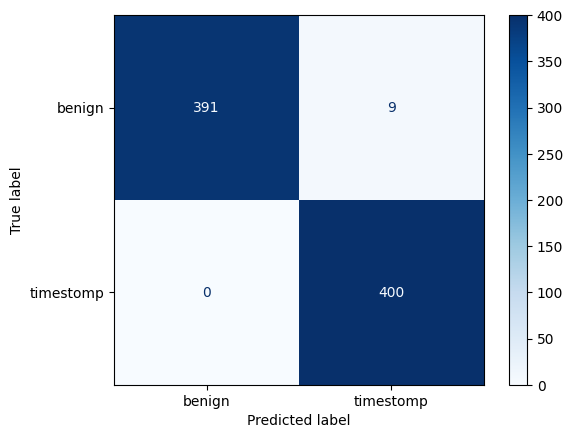

In [59]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

preds = trainer.predict(test_ds)
y_true = preds.label_ids
y_pred = np.argmax(preds.predictions, axis=1)

cm = confusion_matrix(y_true, y_pred, labels=[0,1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["benign","timestomp"])
disp.plot(cmap="Blues")
plt.show()

## Rule based detection

In [62]:
def rule_based_detect(row):
    """
    row: [created, modified, accessed, delta1, delta2, entropy]
    Returns 1 if timestomp anomaly detected, else 0 (benign).
    """
    created, modified, accessed, d1, d2, entropy = row
    if modified < created or accessed < modified:
        return 1  # timestomp
    return 0  # benign

Rule-based accuracy: 0.8825


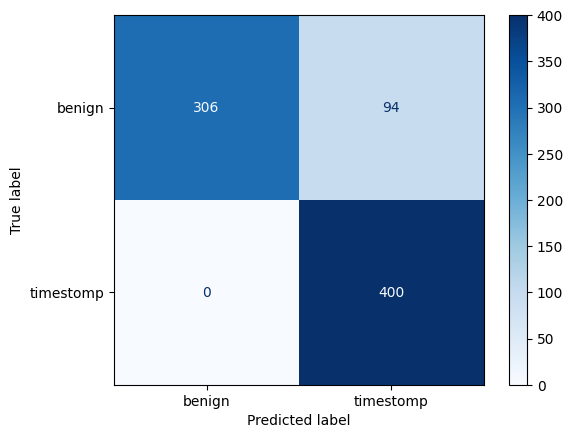

In [63]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Apply rule-based detection
y_pred_rule = [rule_based_detect(x) for x in X_test]

# Accuracy
acc = accuracy_score(y_test, y_pred_rule)
print("Rule-based accuracy:", acc)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_rule, labels=[0,1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["benign","timestomp"])
disp.plot(cmap="Blues")
plt.show()

In [64]:
# import torch

# # Save just the model weights
# torch.save(hf_model.state_dict(), "timestomp_model.pt")

# # Save the scaler too (using joblib or pickle)
# import joblib
# joblib.dump(scaler, "scaler.pkl")


['scaler.pkl']

In [65]:
# from google.colab import files
# files.download("timestomp_model.pt")
# files.download("scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [67]:
# from google.colab import drive
# drive.mount('/content/drive')

# !cp timestomp_model.pt /content/drive/MyDrive/
# !cp scaler.pkl /content/drive/MyDrive/

Mounted at /content/drive
